In [1]:
import polars as pl
import requests
import io
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

In [2]:
# Fetch Open-Meteo shortwave radiation data for Australian regions
REGION_DEFAULTS = {
    "NSW1": {"lat": -33.8688, "lon": 151.2093, "tz": "Australia/Sydney"},   # Sydney
    "VIC1": {"lat": -37.8136, "lon": 144.9631, "tz": "Australia/Melbourne"},# Melbourne
    "QLD1": {"lat": -27.4698, "lon": 153.0251, "tz": "Australia/Brisbane"}, # Brisbane
    "SA1":  {"lat": -34.9285, "lon": 138.6007, "tz": "Australia/Adelaide"}, # Adelaide
    "TAS1": {"lat": -42.8821, "lon": 147.3272, "tz": "Australia/Hobart"},   # Hobart
}

def fetch_open_meteo_shortwave_radiation_polars(
    start_dt: datetime,
    end_dt: datetime,
    latitude: float,
    longitude: float,
    timezone: str,
) -> pl.DataFrame:
    """
    Fetch hourly shortwave radiation (W/m^2) from Open-Meteo archive for a date range.
    Returns a Polars DataFrame with columns: ['time', 'shortwave_radiation'].
    """
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": start_dt.date().isoformat(),
        "end_date": end_dt.date().isoformat(),
        "hourly": "shortwave_radiation",
        "timezone": timezone,
    }
    r = requests.get(url, params=params, timeout=60)
    r.raise_for_status()
    data = r.json()
    hourly = data.get("hourly", {})
    times = hourly.get("time", [])
    swr = hourly.get("shortwave_radiation", [])
    if not times or not swr:
        raise ValueError("Open-Meteo returned no hourly radiation data for the requested range.")
    return pl.DataFrame({"time": times, "shortwave_radiation": swr}).with_columns(
        pl.col("time").str.to_datetime().alias("time"),
        pl.col("shortwave_radiation").cast(pl.Float32)
    )

shape: (36, 2)
┌─────────────────────┬─────────────────────┐
│ time                ┆ shortwave_radiation │
│ ---                 ┆ ---                 │
│ datetime[μs]        ┆ f32                 │
╞═════════════════════╪═════════════════════╡
│ 2023-01-01 06:00:00 ┆ 1.0                 │
│ 2023-01-01 07:00:00 ┆ 69.0                │
│ 2023-01-01 08:00:00 ┆ 238.0               │
│ 2023-01-01 09:00:00 ┆ 443.0               │
│ 2023-01-01 10:00:00 ┆ 561.0               │
│ …                   ┆ …                   │
│ 2023-01-03 13:00:00 ┆ 921.0               │
│ 2023-01-03 14:00:00 ┆ 1021.0              │
│ 2023-01-03 15:00:00 ┆ 810.0               │
│ 2023-01-03 16:00:00 ┆ 745.0               │
│ 2023-01-03 17:00:00 ┆ 644.0               │
└─────────────────────┴─────────────────────┘


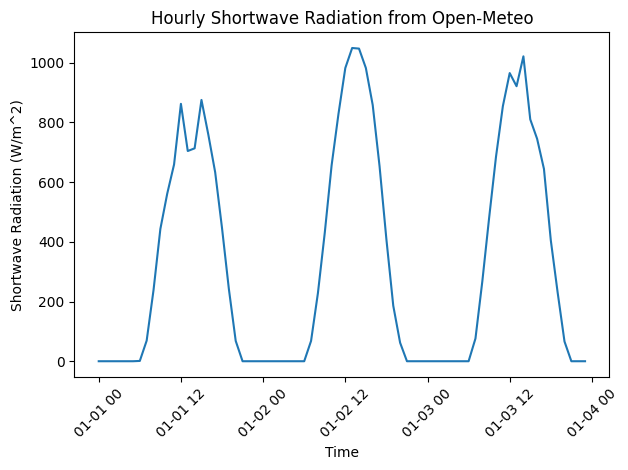

In [3]:
# Example usage
rad_df = fetch_open_meteo_shortwave_radiation_polars(
    start_dt=datetime(2023, 1, 1),
    end_dt=datetime(2023, 1, 3),
    latitude=-33.8688,
    longitude=151.2093,
    timezone="Australia/Sydney"
)
# print times between 6 AM and 6 PM and plot it
print(rad_df.filter(
    (pl.col("time").dt.hour() >= 6) & (pl.col("time").dt.hour() < 18)
))
import matplotlib.pyplot as plt
plt.plot(
    rad_df["time"].to_list(),
    rad_df["shortwave_radiation"].to_list()
)
plt.xlabel("Time")
plt.ylabel("Shortwave Radiation (W/m^2)")
plt.title("Hourly Shortwave Radiation from Open-Meteo")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
# Convert radiation to PV power at higher temporal resolution
# --- stochastic sub-hour upsampling from hourly GHI ---
def upsample_radiation_stochastic(
    hourly_rad_df: pl.DataFrame,
    interval_minutes: int,
    solar_max_output: float,
    noise_scale: float = 0.12,
    seed: int | None = None,
) -> pl.DataFrame:
    """
    Improved physically-plausible upsampling:
     - base linear interpolation from hourly GHI
     - per-day volatility estimate (based on daylight-hour CF variability)
     - correlated (smoothed) noise with day-dependent correlation length
     - occasional smooth cloud events on volatile days
    Returns Polars DF with columns: time, shortwave_radiation, PV
    """
    rng = np.random.default_rng(seed)

    # source arrays
    src_times = hourly_rad_df["time"].to_numpy()
    src_epoch = np.array([t.astype("datetime64[ns]").astype(np.int64) for t in src_times])
    src_rad = hourly_rad_df["shortwave_radiation"].to_numpy().astype(float)

    # target time grid (ns resolution for Polars)
    start = src_times[0]
    end = src_times[-1] + np.timedelta64(1, "h")
    tgt = np.arange(
        start.astype("datetime64[m]"),
        end.astype("datetime64[m]"),
        np.timedelta64(interval_minutes, "m")
    ).astype("datetime64[ns]")
    tgt_epoch = np.array([t.astype("datetime64[ns]").astype(np.int64) for t in tgt])

    # deterministic interpolation
    rad_interp = np.interp(tgt_epoch, src_epoch, src_rad, left=src_rad[0], right=src_rad[-1]).astype(np.float32)

    # capacity factor (clipped)
    cf = np.clip(rad_interp / 1000.0, 0.0, 1.0)

    # --- per-day volatility estimate from hourly data (daylight only) ---
    # compute hourly CF per day (from src arrays)
    src_cf = np.clip(src_rad / 1000.0, 0.0, 1.0)
    src_days = src_times.astype("datetime64[D]")
    unique_days, day_idx = np.unique(src_days, return_inverse=True)
    day_vol = {}
    for i, d in enumerate(unique_days):
        day_mask = day_idx == i
        daylight = src_cf[day_mask] > 0.01  # ignore night zeros
        if daylight.sum() >= 2:
            v = float(np.nanstd(src_cf[day_mask][daylight]) / (np.nanmean(src_cf[day_mask][daylight]) + 1e-6))
            day_vol[d] = np.clip(v, 0.0, 1.0)
        else:
            day_vol[d] = 0.0

    # map volatility to per-sample noise scale and correlation length
    tgt_days = tgt.astype("datetime64[D]")
    noise_scale_array = np.empty(len(tgt), dtype=float)
    corr_minutes_array = np.empty(len(tgt), dtype=float)
    for i, d in enumerate(unique_days):
        mask = tgt_days == d
        vol = day_vol.get(d, 0.0)
        # noise scale increases with volatility (min noise_scale .. ~3x)
        noise_scale_array[mask] = noise_scale * (1.0 + 2.5 * vol)
        # calmer days -> longer correlation (smoother), volatile -> short correlation
        corr_minutes_array[mask] = np.interp(vol, [0.0, 1.0], [60.0, 5.0])

    # ensure reasonable minima
    corr_minutes_array = np.clip(corr_minutes_array, interval_minutes, 24 * 60)

    # --- build correlated noise via Gaussian smoothing of white noise ---
    white = rng.normal(size=len(tgt)).astype(np.float32)
    # build a kernel per unique correlation length to avoid per-sample convolution cost
    conv_noise = np.empty_like(white)
    for corr in np.unique(corr_minutes_array):
        mask = corr_minutes_array == corr
        sigma_samples = max(1.0, corr / interval_minutes)
        half_width = max(3, int(4.0 * sigma_samples))
        x = np.arange(-half_width, half_width + 1)
        kernel = np.exp(-0.5 * (x / sigma_samples) ** 2)
        kernel = kernel / kernel.sum()
        # convolve full white noise then select masked indices (efficient enough for modest sizes)
        smooth_full = np.convolve(white, kernel, mode="same")
        conv_noise[mask] = smooth_full[mask]

    # scale correlated noise by per-sample noise scale
    noise_corr = -np.abs(conv_noise) * noise_scale_array

    # --- occasional smooth cloud events on volatile days ---
    # For each day, possibly insert 0..N events reducing CF smoothly
    unique_tgt_days = np.unique(tgt_days)
    for d in unique_tgt_days:
        vol = day_vol.get(d, 0.0)
        # probability and number of events scale with volatility
        if rng.random() < (0.05 + 0.45 * vol):
            num_events = rng.integers(1, 1 + int(1 + 3 * vol))
            day_mask = np.where(tgt_days == d)[0]
            if len(day_mask) == 0:
                continue
            for _ in range(num_events):
                start_idx = rng.choice(day_mask)
                max_dur_steps = max(1, int(min(12 * 60 / interval_minutes, len(day_mask))))  # up to 12h in steps
                dur_steps = rng.integers(1, max(2, int(1 + vol * max_dur_steps)))
                end_idx = min(start_idx + dur_steps, day_mask[-1] + 1)
                if end_idx <= start_idx:
                    continue
                # smooth ramp using half-cosine
                span = end_idx - start_idx
                ramp = 0.5 * (1 - np.cos(np.linspace(0, np.pi, span)))
                reduction = float(np.clip(rng.normal(loc=0.45, scale=0.15) * (0.5 + vol), 0.15, 0.95))
                # apply multiplicative reduction to cf (not to noise_corr)
                cf[start_idx:end_idx] = cf[start_idx:end_idx] * (1.0 - reduction * ramp)

    # apply correlated multiplicative noise, then clip
    cf_noisy = np.clip(cf * (1.0 + noise_corr), 0.0, 1.0)

    pv = (solar_max_output * cf_noisy).astype(np.float32)

    return pl.DataFrame({"time": tgt, "shortwave_radiation": rad_interp, "PV": pv})


shape: (5, 3)
┌─────────────────────┬─────────────────────┬─────┐
│ time                ┆ shortwave_radiation ┆ PV  │
│ ---                 ┆ ---                 ┆ --- │
│ datetime[ns]        ┆ f32                 ┆ f32 │
╞═════════════════════╪═════════════════════╪═════╡
│ 2023-01-01 00:00:00 ┆ 0.0                 ┆ 0.0 │
│ 2023-01-01 00:05:00 ┆ 0.0                 ┆ 0.0 │
│ 2023-01-01 00:10:00 ┆ 0.0                 ┆ 0.0 │
│ 2023-01-01 00:15:00 ┆ 0.0                 ┆ 0.0 │
│ 2023-01-01 00:20:00 ┆ 0.0                 ┆ 0.0 │
└─────────────────────┴─────────────────────┴─────┘


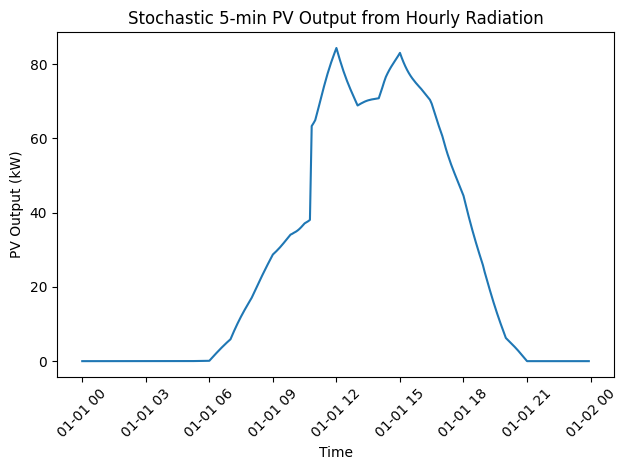

In [23]:
# Stochastic 5‑min PV from hourly Open-Meteo
rad_stoch_5m = upsample_radiation_stochastic(rad_df, interval_minutes=5, solar_max_output=100.0, noise_scale=0.1, seed=42)
print(rad_stoch_5m.head())

# plot the 5-min PV time series for the first day
first_day = rad_stoch_5m.filter(
    (pl.col("time") >= datetime(2023, 1, 1)) & (pl.col("time") < datetime(2023, 1, 2))
)
plt.plot(
    first_day["time"].to_list(),
    first_day["PV"].to_list()
)
plt.xlabel("Time")
plt.ylabel("PV Output (kW)")
plt.title("Stochastic 5-min PV Output from Hourly Radiation")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# Simple deterministic interpolation from hourly radiation to PV power
def radiation_to_pv_power_polars(
    target_times: pl.Series,
    hourly_radiation_df: pl.DataFrame,
    solar_max_output: float,
) -> np.ndarray:
    """
    Convert shortwave radiation (W/m^2) to PV plant output using a simple linear model:
      PV = solar_max_output * clamp(radiation / 1000, 0..1)
    Interpolates from hourly points onto target_times (as Polars Series).
    Returns a numpy array.
    """
    src_times = hourly_radiation_df["time"].to_numpy()
    src_epoch = np.array([t.astype('datetime64[ns]').astype(np.int64) for t in src_times])
    src_rad = hourly_radiation_df["shortwave_radiation"].to_numpy()
    cf = np.clip(src_rad / 1000.0, 0.0, 1.0)
    pv_hourly = solar_max_output * cf

    tgt_times = target_times.to_numpy()
    tgt_epoch = np.array([t.astype('datetime64[ns]').astype(np.int64) for t in tgt_times])

    pv_interp = np.interp(tgt_epoch, src_epoch, pv_hourly, left=pv_hourly[0], right=pv_hourly[-1])
    return pv_interp.astype(np.float32)

In [15]:
# Example: Convert radiation to PV output for a 100 MW plant
# Use the rad_df from above and create a target_times series (e.g., every 30 min for 2 days)
import numpy as np
import polars as pl

# Create 5-min intervals for Jan 1-3, 2023 (inclusive start, exclusive end)
start_ns = np.datetime64("2023-01-01T00:00", "ns").astype("int64")
end_ns =   np.datetime64("2023-01-03T00:00", "ns").astype("int64")
step_30m = int(np.timedelta64(30, "m") / np.timedelta64(1, "ns"))

tgt_30m = np.arange(start_ns, end_ns, step_30m).astype("datetime64[ns]")
target_times = pl.Series("Time", tgt_30m)

# Example: 5-minute resolution
step_5m = int(np.timedelta64(5, "m") / np.timedelta64(1, "ns"))
tgt_5m = np.arange(start_ns, end_ns, step_5m).astype("datetime64[ns]")
target_times_5m = pl.Series("Time", tgt_5m)

pv = radiation_to_pv_power_polars(
    target_times=target_times_5m,
    hourly_radiation_df=rad_df,
    solar_max_output=100.0  # 100 MW
)


In [16]:
print(len(pv))

576


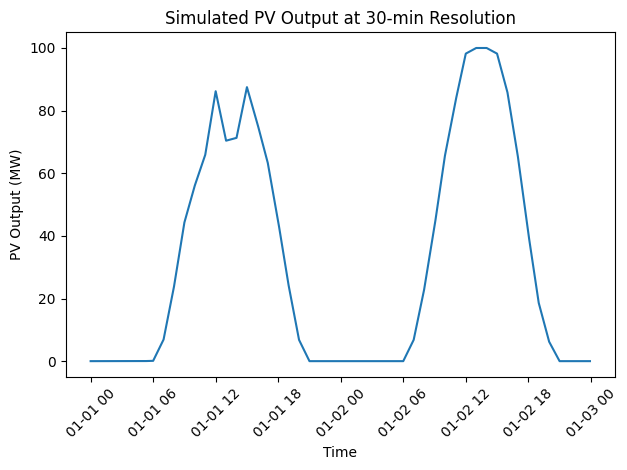

In [10]:
# plot pv output at 30 min resolution
plt.plot(
    target_times.to_list(),
    pv.tolist()
)
plt.xlabel("Time")
plt.ylabel("PV Output (MW)")
plt.title("Simulated PV Output at 30-min Resolution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
# Fetch AEMO aggregated price and demand data from CSV archive
def fetch_aemo_aggregated_data(year: int, month: int, region: str) -> pl.DataFrame:
    """
    Fetches aggregated price and demand data directly from AEMO's CSV archive.
    
    Args:
        year: The year to fetch (e.g., 2023)
        month: The month to fetch (e.g., 1 for January)
        region: The NEM region (e.g., 'NSW1', 'VIC1', 'QLD1', 'SA1', 'TAS1')
        
    Returns:
        pl.DataFrame: Raw Polars DataFrame containing the CSV data.
    """
    # Format: PRICE_AND_DEMAND_YYYYMM_REGION.csv
    month_str = f"{month:02d}"
    url = f"https://aemo.com.au/aemo/data/nem/priceanddemand/PRICE_AND_DEMAND_{year}{month_str}_{region}.csv"
    
    print(f"Fetching data from: {url}")
    try:
        response = requests.get(url)
        response.raise_for_status()
        
        # Read content into Polars
        # Using pandas first for robust CSV parsing of web streams, then converting to Polars
        # (Polars read_csv sometimes requires a file-like object with specific traits)
        pdf = pd.read_csv(io.StringIO(response.content.decode('utf-8')))
        df = pl.from_pandas(pdf)
        return df
        
    except requests.exceptions.HTTPError as e:
        print(f"Failed to download data: {e}")
        print("Note: AEMO data is generally available for the last ~20 years. Ensure the date is valid.")
        return None
    except Exception as e:
        print(f"An error occurred: {e}")
        return None

In [28]:
# Example: Fetch AEMO price and demand data for NSW1, Jan 2023
df_raw = fetch_aemo_aggregated_data(2023, 1, "NSW1")
print(df_raw.head())

Fetching data from: https://aemo.com.au/aemo/data/nem/priceanddemand/PRICE_AND_DEMAND_202301_NSW1.csv
shape: (5, 5)
┌────────┬─────────────────────┬─────────────┬────────┬────────────┐
│ REGION ┆ SETTLEMENTDATE      ┆ TOTALDEMAND ┆ RRP    ┆ PERIODTYPE │
│ ---    ┆ ---                 ┆ ---         ┆ ---    ┆ ---        │
│ str    ┆ str                 ┆ f64         ┆ f64    ┆ str        │
╞════════╪═════════════════════╪═════════════╪════════╪════════════╡
│ NSW1   ┆ 2023/01/01 00:05:00 ┆ 6906.63     ┆ 140.4  ┆ TRADE      │
│ NSW1   ┆ 2023/01/01 00:10:00 ┆ 6854.28     ┆ 133.96 ┆ TRADE      │
│ NSW1   ┆ 2023/01/01 00:15:00 ┆ 6856.32     ┆ 120.0  ┆ TRADE      │
│ NSW1   ┆ 2023/01/01 00:20:00 ┆ 6796.27     ┆ 118.99 ┆ TRADE      │
│ NSW1   ┆ 2023/01/01 00:25:00 ┆ 6805.55     ┆ 118.99 ┆ TRADE      │
└────────┴─────────────────────┴─────────────┴────────┴────────────┘


In [30]:
# Prepare Grid Simulation Data to create SolarBatteryEnv/GridBatteryEnv compatible DataFrame
def prepare_grid_sim_data(
    df: pl.DataFrame,
    forecast_horizon_steps: int = 48,
    solar_trace: np.array = None,
    *,
    region: str = None,
    latitude: float = None,
    longitude: float = None,
    timezone: str = None,
    solar_max_output: float = 100.0,
    solar_noise_scale: float = 0.1,
    solar_noise_seed: int | None = 42,
) -> pl.DataFrame:
    """
    Transforms raw AEMO data into the format expected by SolarBatteryEnv/GridBatteryEnv.
    If solar_trace is None and solar_max_output > 0, fetches solar radiation for the
    timestamp range + location and synthesizes SolarGen.
    """
    q = (
        df.lazy()
        .select([
            pl.col("SETTLEMENTDATE").str.to_datetime(format="%Y/%m/%d %H:%M:%S").alias("Time"),
            pl.col("TOTALDEMAND").cast(pl.Float32).alias("HouseLoad"),
            pl.col("RRP").cast(pl.Float32).alias("ImportEnergyPrice"),
        ])
        .with_columns([
            pl.col("ImportEnergyPrice").alias("ExportEnergyPrice"),
            pl.col("Time").alias("Timestamp"),
        ])
    )
    processed_df = q.collect()

    # 2. Add Solar/Generation Component
    if solar_trace is not None:
        if len(solar_trace) != len(processed_df):
            min_len = min(len(solar_trace), len(processed_df))
            solar_col = pl.Series("SolarGen", solar_trace[:min_len])
            processed_df = processed_df.slice(0, min_len).with_columns(solar_col)
        else:
            processed_df = processed_df.with_columns(pl.Series("SolarGen", solar_trace))
    # if no solar data provided, synthesize from location solar radiation weather data
    else:
        if solar_max_output and solar_max_output > 0:
            if region and region in REGION_DEFAULTS:
                defaults = REGION_DEFAULTS[region]
                latitude = defaults["lat"] if latitude is None else latitude
                longitude = defaults["lon"] if longitude is None else longitude
                timezone = defaults["tz"] if timezone is None else timezone
            if latitude is None or longitude is None:
                raise ValueError(
                    "solar_trace is None and solar_max_output > 0, but no location provided. "
                    "Pass region='NSW1'/'VIC1'/... or pass latitude/longitude."
                )
            if timezone is None:
                timezone = "Australia/Sydney"
            times = processed_df["Time"]
            start_dt = times.min()
            end_dt = times.max()
            rad_df = fetch_open_meteo_shortwave_radiation_polars(
                start_dt=start_dt,
                end_dt=end_dt,
                latitude=float(latitude),
                longitude=float(longitude),
                timezone=str(timezone),
            )

            time_values = times.to_numpy()
            interval_minutes = 30
            if len(time_values) >= 2:
                delta = int((time_values[1] - time_values[0]) / np.timedelta64(1, "m"))
                if delta > 0:
                    interval_minutes = delta
            # Upsample radiation to desired interval with stochastic model
            solar_df = upsample_radiation_stochastic(
                hourly_rad_df=rad_df,
                interval_minutes=interval_minutes,
                solar_max_output=float(solar_max_output),
                noise_scale=float(solar_noise_scale),
                seed=solar_noise_seed,
            ).select(
                pl.col("time").alias("Time"),
                pl.col("PV").alias("SolarGen"),
            )

            # align datetime units with processed_df to avoid SchemaError on join
            solar_df = solar_df.with_columns(
                pl.col("Time").cast(processed_df["Time"].dtype)
            )

            processed_df = processed_df.join(solar_df, on="Time", how="left")
            processed_df = processed_df.with_columns(
                pl.col("SolarGen").fill_null(0.0)
            )
        else:
            processed_df = processed_df.with_columns(pl.lit(0.0).alias("SolarGen"))

    # 3. Create Future/Forecast Columns (Perfect Foresight)
    processed_df = processed_df.with_columns([
        pl.col("SolarGen").shift(-forecast_horizon_steps).fill_null(0.0).alias("FutureSolar"),
        pl.col("HouseLoad").shift(-forecast_horizon_steps).fill_null(pl.col("HouseLoad").mean()).alias("FutureLoad"),
    ])
    processed_df = processed_df.slice(0, len(processed_df) - forecast_horizon_steps)
    return processed_df
# Example Usage Helper
def get_example_grid_data():
    """Download one month of NSW data and prepare it."""
    print("Downloading Jan 2023 NSW1 Data...")
    df_raw = fetch_aemo_aggregated_data(2023, 1, "NSW1")
    if df_raw is not None:
        print("Processing data...")
        df_ready = prepare_grid_sim_data(df_raw)
        print(f"Data ready: {df_ready.shape}")
        return df_ready
    return None

In [31]:
# Example: Prepare grid simulation data with synthetic solar for a 300 MW plant
df_ready = prepare_grid_sim_data(
    df_raw,
    region="NSW1",
    solar_max_output=300.0,  # 300 MW
    forecast_horizon_steps=48
)
print(df_ready.head())

shape: (5, 8)
┌────────────┬────────────┬────────────┬────────────┬───────────┬──────────┬───────────┬───────────┐
│ Time       ┆ HouseLoad  ┆ ImportEner ┆ ExportEner ┆ Timestamp ┆ SolarGen ┆ FutureSol ┆ FutureLoa │
│ ---        ┆ ---        ┆ gyPrice    ┆ gyPrice    ┆ ---       ┆ ---      ┆ ar        ┆ d         │
│ datetime[μ ┆ f32        ┆ ---        ┆ ---        ┆ datetime[ ┆ f32      ┆ ---       ┆ ---       │
│ s]         ┆            ┆ f32        ┆ f32        ┆ μs]       ┆          ┆ f32       ┆ f32       │
╞════════════╪════════════╪════════════╪════════════╪═══════════╪══════════╪═══════════╪═══════════╡
│ 2023-01-01 ┆ 6906.62988 ┆ 140.399994 ┆ 140.399994 ┆ 2023-01-0 ┆ 0.0      ┆ 0.0       ┆ 5847.5297 │
│ 00:05:00   ┆ 3          ┆            ┆            ┆ 1         ┆          ┆           ┆ 85        │
│            ┆            ┆            ┆            ┆ 00:05:00  ┆          ┆           ┆           │
│ 2023-01-01 ┆ 6854.27978 ┆ 133.960007 ┆ 133.960007 ┆ 2023-01-0 ┆ 0.0      ┆ 

In [ ]:
# Define GridBatteryEnv inheriting from SolarBatteryEnv
import gymnasium as gym
import numpy as np
import polars as pl
from EnergySimEnv import SolarBatteryEnv

class GridBatteryEnv(SolarBatteryEnv):
    """
    A Gym environment tailored for Grid-Scale Battery participation in the NEM.
    Inherits from SolarBatteryEnv but adapts specific logic for grid-scale physics and financial metrics.
    """
    def __init__(
        self, 
        df: pl.DataFrame, 
        battery_capacity=1000.0,  # kWh (e.g., 1 MWh battery)
        max_battery_flow=500.0,   # kW (e.g., 0.5 MW power)
        max_grid_flow=10000.0,    # kW (Transmission constraint, often higher than battery rating)
        **kwargs
    ):
        """
        Args:
            df: DataFrame containing 'RRP' (mapped to prices), 'TOTALDEMAND' (mapped to Load), etc.
            battery_capacity: Default to larger grid-scale size (1MWh)
            max_battery_flow: Default to larger grid-scale power (500kW)
        """
        # Call parent init with grid-scale defaults
        super().__init__(
            df=df,
            battery_capacity=battery_capacity,
            max_battery_flow=max_battery_flow,
            max_grid_flow=max_grid_flow,
            **kwargs
        )
        
        # Override specific internal parameters if needed
        # For grid batteries, 'violation' penalties might need scaling if demand/supply figures are massive.
        # However, since we normalize observations, the policy learning should be stable.

    def _calculate_grid_reward(self, grid_energy, energy_price):
        """
        Custom reward calculation for Grid Market.
        
        In the household env:
         - Import (grid_energy > 0) = Cost
         - Export (grid_energy < 0) = Feed-in Tariff (often lower than import)
         
        In the Grid Market (NEM):
         - Spot price applies symmetrically (ignoring marginal loss factors for simplicity).
         - Negative prices mean you get PAID to charge (Import).
        """
        
        # Parent class implementation: reward = -(grid_energy * energy_price)
        # This is actually mathematically correct for Spot Markets too:
        # If Price is -$50:
        #   Charging 10kWh (grid_energy = +10): Reward = -(10 * -50) = +500 (Earn $500) -> Correct
        #   Discharging 10kWh (grid_energy = -10): Reward = -(-10 * -50) = -500 (Pay $500 to generate) -> Correct
        
        # We can add a small transaction cost or 'bid spread' penalty here if we want more realism.
        # For now, the base implementation is mathematically consistent with the NEM.
        
        return super()._calculate_grid_reward(grid_energy, energy_price)

    def render(self, **kwargs):
        if self.render_mode == 'human':
            # Customized print for Grid context
            # Accessing columns that might have been renamed in preparation
            price = self.df['ImportEnergyPrice'][self.current_step]
            demand = self.df['HouseLoad'][self.current_step]
            print(f"Step: {self.current_step} | "
                  f"SoC: {self.battery_level:.1f} kWh | "
                  f"Price: ${price:.2f} | "
                  f"Grid Demand: {demand:.2f} MW")
        else:
            super().render(**kwargs)